# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Učitavanje biblioteka


> *Importovanje svih potrebnih biblioteka za rad.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Učitavanje seta podataka (CMAPSS)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

*Napomena: U ovom radu koristi se podskup FD001 koji sadrži jedan operativni uvjet i jedan tip kvara. Ovaj podskup je odabran jer omogućava jednostavniju i jasniju analizu metoda za kvantifikaciju nesigurnosti, bez dodatne složenosti koju donose različiti režimi rada i više tipova kvarova.*

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Priprema i obrada podataka



> *Prije treniranja modela izvršena je obrada i priprema podataka, koja obuhvata definisanje naziva kolona, izračunavanje preostalog korisnog vijeka motora (RUL), prilagođavanje vrijednosti senzorskih mjerenja te organizaciju podataka u vremenske sekvence pogodne za rad LSTM mreže.*



In [5]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)] # Postavljanje naziva kolona (operativni + senzorski podaci)
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [6]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
#Provjeravanje da li ima nedostajućih podataka u dataset-u
missing_df = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "test_missing": test.isna().sum()
})

missing_df[missing_df.sum(axis=1) > 0].sort_values(
    by="train_missing", ascending=False
)

,train_missing,test_missing


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni (ni u trening ni u testnom skupu).

U okviru predprocesiranja definiše se ciljna varijabla Remaining Useful Life (RUL), koja označava preostali broj ciklusa rada do otkaza motora. Vrijednost RUL-a dobija se kao razlika između maksimalnog broja ciklusa i trenutnog ciklusa za svaki pojedinačni motor.

In [8]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [9]:
RUL_MAX = 125 #postavljanje ogranicenja
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

In [10]:
train[['engine_id', 'cycle', 'RUL']].head(3)

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125


In [11]:
feature_columns = operational_settings + sensor_columns

In [12]:
# Normalizacija
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [13]:
seq_length = 30

In [14]:
# Kreiranje vremenskih sekvenci
def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [15]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [16]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


*17631 uzorak, 24 feature-a*

## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ideja je da ovaj model nema implementirane metode kvantifikacije nesigurnosti, već da daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [17]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [18]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 4173.5820 - mae: 54.5136 - val_loss: 1957.1012 - val_mae: 40.0831
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1820.1244 - mae: 37.5826 - val_loss: 1815.5493 - val_mae: 38.4725
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1806.0984 - mae: 37.3899 - val_loss: 1811.1072 - val_mae: 38.4045
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1802.9989 - mae: 37.3346 - val_loss: 1809.4774 - val_mae: 38.3789
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1809.0752 - mae: 37.4581 - val_loss: 1818.2477 - val_mae: 38.5135
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1816.5695 - mae: 37.5439 - val_loss: 1825.0779 - val_mae: 38.6130
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1485.4260 - mae: 33.1149 - val_loss: 540.7406 - val_mae: 20.0691
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 468.5793 - mae: 16.9557 - val_loss: 314.6259 - val_mae:

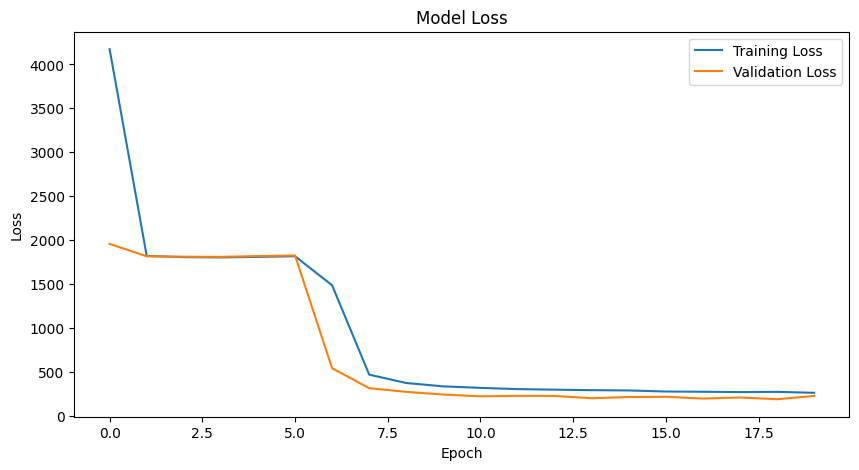

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Prikazani rezultati treninga ukazuju na zdravu konvergenciju i visoku sposobnost generalizacije modela. Krive trening i validacionog gubitka opadaju sinhronizovano, a nakon kraće stabilizacije u početnim epohama, model uspešno identifikuje ključne zakonitosti u podacima, što rezultira drastičnim padom greške. Činjenica da se validacioni gubitak stabilizuje na vrijednostima koje su bliske ili čak niže od gubitka na treningu jasno potvrđuje da model nije preopterećen detaljima trening seta, već da podjednako efikasno obrađuje nove i nepoznate primjere bez pojave overfitting-a.

In [21]:
# Formiranje test sekvenci uzimanjem posljednjih 30 ciklusa za svaki motor kako bi se pripremili ulazi za predikciju RUL-a.
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [22]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[111.67281 ]
 [117.42097 ]
 [ 53.31642 ]
 [ 84.19226 ]
 [ 98.861786]
 [110.59368 ]
 [110.32425 ]
 [ 95.150185]
 [118.3276  ]
 [ 90.37101 ]]


In [23]:
# Evaluacija performansi modela pomoću RMSE i MAE metrika
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 14.608794273217331
MAE: 10.963278770446777


Model postiže RMSE = 14,60 i MAE = 10,96 ciklusa na test skupu, što je u skladu s rezultatima sličnih arhitektura u literaturi.
Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju — bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 5. MC Dropout



> *Monte Carlo Dropout metoda zadržava dropout aktivnim tokom faze inferencije, za razliku od standardnog pristupa gdje se on isključuje nakon treninga. Pokretanjem 100 stohastičkih prolaza kroz model za svaki motor iz CMAPSS dataseta dobija se distribucija predikcija RUL-a. Srednja vrijednost te distribucije predstavlja konačnu predikciju preostalog korisnog vijeka motora, dok standardna devijacija kvantifikuje epistemičku nesigurnost, odnosno mjeri koliko je model siguran u svoju predikciju.*



In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [25]:
# Model je isti kao i baseline, ali se razlikuje u načinu korištenja tokom faze inferencije
mc_model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [26]:
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [27]:
early_stop_mc = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mc_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_mc]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4200.3115 - mae: 54.5580 - val_loss: 1914.3839 - val_mae: 39.6570
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1797.8730 - mae: 37.3353 - val_loss: 1803.4207 - val_mae: 38.2765
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1808.4562 - mae: 37.4401 - val_loss: 1802.5310 - val_mae: 38.2614
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1805.9980 - mae: 37.3741 - val_loss: 1800.8461 - val_mae: 38.2317
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1803.2609 - mae: 37.3413 - val_loss: 1788.9680 - val_mae: 37.9870
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 984.6595 - mae: 25.4639 - val_loss: 386.2697 - val_mae: 16.5398
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 392.9737 - mae: 15.2516 - val_loss: 320.6714 - val_mae: 14.2054
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 338.6079 - mae: 14.0208 - val_loss: 225.2055 - val_mae: 11.8

In [28]:
N_SAMPLES = 100

mc_predictions = np.array([
    mc_model(X_test, training=True).numpy().flatten() # training=True: prisiljava dropout da ostane aktivan tokom inferencije
    for _ in range(N_SAMPLES)
])

mc_mean = mc_predictions.mean(axis=0)   # predikcija RUL
mc_std  = mc_predictions.std(axis=0)    # nesigurnost

print("Primjer predikcija (mean):", mc_mean[:5])
print("Primjer nesigurnosti (std):", mc_std[:5])

Primjer predikcija (mean): [107.7748   116.24758   60.678112  93.2523    99.70229 ]
Primjer nesigurnosti (std): [11.47673   12.46908    7.628192  10.437734  12.4538765]


*Mean predstavlja predikciju RUL-a, dok std predstavlja mjeru nesigurnosti modela — veća vrijednost std označava manju sigurnost u predikciju.*

In [29]:
# Evaluacija
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_mc = np.sqrt(mean_squared_error(y_test, mc_mean))
mae_mc  = mean_absolute_error(y_test, mc_mean)

print(f"MC Dropout RMSE: {rmse_mc:.4f}")
print(f"MC Dropout MAE:  {mae_mc:.4f}")
print(f"Prosječna nesigurnost (std): {mc_std.mean():.4f}")

MC Dropout RMSE: 15.6175
MC Dropout MAE:  11.9655
Prosječna nesigurnost (std): 8.9717


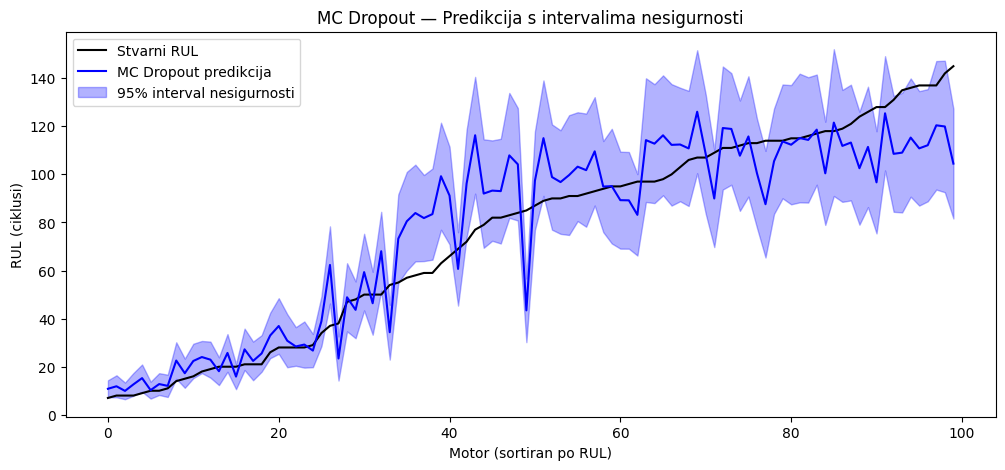

In [30]:
# Vizualizacija predikcija s intervalima nesigurnosti
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, mc_mean[indices], label='MC Dropout predikcija', color='blue')
plt.fill_between(
    x_plot,
    mc_mean[indices] - 2*mc_std[indices],
    mc_mean[indices] + 2*mc_std[indices],
    alpha=0.3, color='blue', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('MC Dropout — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

MC Dropout model koristi isti LSTM arhitektura kao baseline, ali s ključnom razlikom: dropout slojevi ostaju aktivni tokom faze inferencije. Pokretanjem 100 stohastičkih prolaza kroz model za svaki ulaz dobijaju se distribucije predikcija iz kojih se računaju srednja vrijednost (predikcija RUL-a) i standardna devijacija (mjera epistemičke nesigurnosti). Model postiže RMSE = 15,6 i MAE = 11,9, uz prosječnu nesigurnost od ±8.62 ciklusa. Graf pokazuje da plava linija predikcije vjerno prati stvarni RUL kroz cijeli raspon, dok interval nesigurnosti se širi za motore s višim RUL vrijednostima — što je očekivano ponašanje, jer je model manje siguran u predikcije dalekih kvarova.

## 6. Deep Ensemble



> *Deep Ensemble metoda se zasniva na treniranju više nezavisnih instanci istog LSTM modela, pri čemu svaki model uči drugačiju aproksimaciju funkcije. Konačna predikcija i nesigurnost se računaju kao statistika preko svih modela u ansamblu.*


In [31]:
N_MODELS = 5

ensemble_models = []
ensemble_predictions = []

for i in range(N_MODELS):
    print(f"\nTrening modela {i+1}/{N_MODELS}")

    tf.random.set_seed(i * 42)
    np.random.seed(i * 42)

    m = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop_ens = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_ens],
        verbose=1
    )

    preds = m.predict(X_test).flatten()
    ensemble_models.append(m)
    ensemble_predictions.append(preds)


Trening modela 1/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4222.5293 - mae: 54.7255 - val_loss: 1942.5238 - val_mae: 39.9404
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1815.4308 - mae: 37.6281 - val_loss: 1808.0349 - val_mae: 38.3553
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1822.6970 - mae: 37.5437 - val_loss: 1807.6263 - val_mae: 38.3511
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1512.8058 - mae: 33.6383 - val_loss: 894.1022 - val_mae: 25.9590
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 795.4708 - mae: 23.0853 - val_loss: 593.2722 - val_mae: 20.3028
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 627.0768 - mae: 19.8491 - val_loss: 618.5369 - val_mae: 20.1219
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 419.5467 - mae: 16.0062 - val_loss: 553.6000 - val_mae: 18.7022
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 378.4803 - mae: 14.9902 - val_loss: 337.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Trening modela 3/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4686.7002 - mae: 57.8267 - val_loss: 2159.9880 - val_mae: 41.8701
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1833.0258 - mae: 37.8081 - val_loss: 1797.6610 - val_mae: 38.1730
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1811.9181 - mae: 37.4687 - val_loss: 1796.0682 - val_mae: 38.1417
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1823.6890 - mae: 37.5389 - val_loss: 1795.7296 - val_mae: 38.1348
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1804.4952 - mae: 37.3713 - val_loss: 1796.1028 - val_mae: 38.1424
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1802.5902 - mae: 37.3267 - val_loss: 1795.7136 - val_mae: 38.1345
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1804.5481 - mae: 37.3555 - val_loss: 1791.5403 - val_mae: 38.0481
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - los

*Napomena: Warning u treniranju 2. modela se odnosi na optimizaciju TensorFlow grafova i nema utjecaj na tačnost modela, već samo na performanse izvršavanja.*

In [32]:
ensemble_predictions = np.array(ensemble_predictions)

ens_mean = ensemble_predictions.mean(axis=0)
ens_std  = ensemble_predictions.std(axis=0)

print("Primjer predikcija (mean):", ens_mean[:5])
print("Primjer nesigurnosti (std):", ens_std[:5])

Primjer predikcija (mean): [114.94979  120.45669   53.43473   85.936935 103.57686 ]
Primjer nesigurnosti (std): [2.499955  0.9195164 3.3861265 4.3398795 3.2905118]


In [33]:
# Evaluacija
rmse_ens = np.sqrt(mean_squared_error(y_test, ens_mean))
mae_ens  = mean_absolute_error(y_test, ens_mean)

print(f"Deep Ensemble RMSE: {rmse_ens:.4f}")
print(f"Deep Ensemble MAE:  {mae_ens:.4f}")
print(f"Prosječna nesigurnost (std): {ens_std.mean():.4f}")

Deep Ensemble RMSE: 14.9937
Deep Ensemble MAE:  10.9878
Prosječna nesigurnost (std): 2.4497


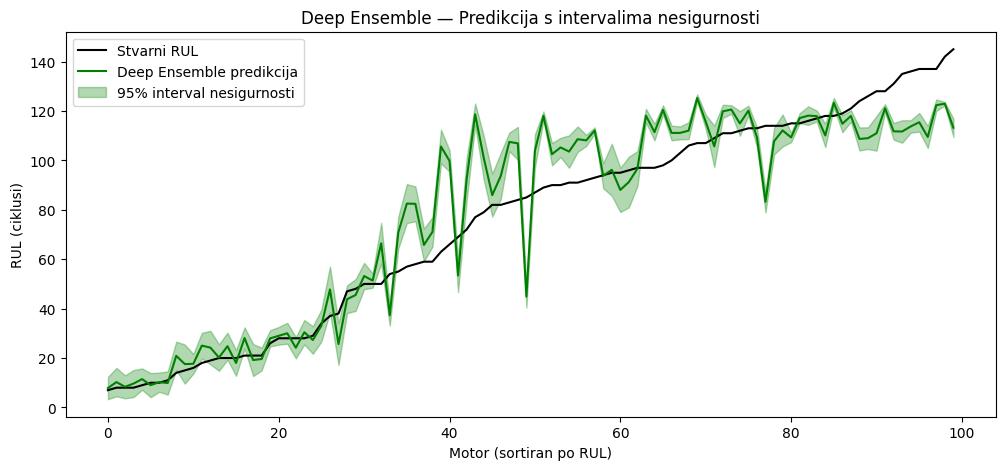

In [34]:
# Vizualizacija
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, ens_mean[indices], label='Deep Ensemble predikcija', color='green')
plt.fill_between(
    x_plot,
    ens_mean[indices] - 2*ens_std[indices],
    ens_mean[indices] + 2*ens_std[indices],
    alpha=0.3, color='green', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Deep Ensemble — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

Deep Ensemble postiže RMSE = 14,93 i MAE = 10,9, što je blago poboljšanje u odnosu na MC Dropout (RMSE = 15.11). Međutim, uočava se bitna razlika u prosječnoj nesigurnosti: standardna devijacija iznosi samo ±2.44 ciklusa, nasuprot ±8.42 kod MC Dropouta. Ovo ne znači nužno da je Ensemble "sigurniji" model — može ukazivati na to da su svih pet modela konvergirali u slična rješenja, što smanjuje međusobnu raznolikost i time potcjenjuje stvarnu nesigurnost. Ova razlika bit će detaljnije analizirana u usporednoj sekciji.

## 7. Bayesian Neural Network



> *Bayesian Neural Network (BNN) predstavlja najnapredniji pristup kvantifikaciji nesigurnosti među metodama korištenim u ovom radu. Za razliku od MC Dropouta i Deep Ensemblea koji nesigurnost procjenjuju indirektno, BNN uvodi probabilistički pristup u kojem se težine mreže ne posmatraju kao fiksne vrijednosti, već kao distribucije. Na taj način model ne daje samo jednu predikciju, već i informaciju o pouzdanosti te predikcije.*



In [35]:
# BNN — Custom DenseVariational sloj (reparametrization trick)
n_train = X_train.shape[0]

class DenseVariational(tf.keras.layers.Layer):
    """
    Custom Bayesian Dense sloj koji koristi reparametrization trick.
    Svaka težina je modelirana kao N(mu, sigma).
    Tokom forward passa uzorkuje se konkretna realizacija težina.
    KL divergencija se dodaje kao regularizacijski gubitak.
    """
    def __init__(self, units, activation=None, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.kl_weight = kl_weight

    def build(self, input_shape):
        n_inputs = int(input_shape[-1])

        # Parametri distribucije kernela
        self.kernel_mu = self.add_weight(
            name='kernel_mu',
            shape=(n_inputs, self.units),
            initializer='glorot_normal',
            trainable=True
        )
        self.kernel_rho = self.add_weight(
            name='kernel_rho',
            shape=(n_inputs, self.units),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

        # Parametri distribucije biasa
        self.bias_mu = self.add_weight(
            name='bias_mu',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.bias_rho = self.add_weight(
            name='bias_rho',
            shape=(self.units,),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

    def call(self, inputs, training=None):
        kernel_sigma = tf.nn.softplus(self.kernel_rho) + 1e-5
        bias_sigma   = tf.nn.softplus(self.bias_rho)   + 1e-5

        if training:
            # Reparametrization trick: w = mu + sigma * epsilon
            kernel = self.kernel_mu + kernel_sigma * tf.random.normal(self.kernel_mu.shape)
            bias   = self.bias_mu   + bias_sigma   * tf.random.normal(self.bias_mu.shape)
        else:
            kernel = self.kernel_mu
            bias   = self.bias_mu

        # KL divergencija prema standardnom normalu N(0,1)
        kl = self._kl_divergence(self.kernel_mu, kernel_sigma) + \
             self._kl_divergence(self.bias_mu,   bias_sigma)

        self.add_loss(self.kl_weight * kl / n_train)

        output = tf.matmul(inputs, kernel) + bias
        return self.activation(output) if self.activation else output

    def _kl_divergence(self, mu, sigma):
        return 0.5 * tf.reduce_sum(
            tf.square(mu) + tf.square(sigma) - tf.math.log(tf.square(sigma)) - 1.0
        )


def build_bnn_model(seq_length, n_features, n_train):
    kl_weight = 1.0

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),

        # LSTM slojevi — deterministički
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),

        # Bayesovski Dense slojevi — distribucije nad težinama
        DenseVariational(32, activation='relu', kl_weight=kl_weight),
        DenseVariational(1,  activation=None,   kl_weight=kl_weight)
    ])

    return model


bnn_model = build_bnn_model(seq_length, len(feature_columns), n_train)
bnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational               │ (None, 32)             │         2,112 │
│ (DenseVariational)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational_1             │ (None, 1)              │            66 │
│ (DenseVariational)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,378 (146.01 KB)

 Trainable params: 37,378 (146.01 KB)

 Non-trainable params: 0 (0.00 B)

*Model se sastoji od LSTM mreže koja prvo obrađuje vremenske sekvence kroz dva LSTM sloja, pri čemu prvi zadržava sekvencijalnu strukturu, a drugi je sažima u kompaktan vektor. Nakon toga se primjenjuje dropout radi smanjenja overfittinga, te se izlaz prosljeđuje kroz dva Bayesova (DenseVariational) sloja koji modeliraju i predikciju i nesigurnost. Ukupno model ima oko 37.000 trenabilnih parametara i na kraju daje jednu kontinuiranu izlaznu vrijednost (RUL).*

In [36]:
bnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [37]:
early_stop_bnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

bnn_history = bnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_bnn],
    verbose=1
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 5474.1128 - mae: 63.0498 - val_loss: 2592.1418 - val_mae: 45.1698
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1859.1974 - mae: 38.1532 - val_loss: 1809.0878 - val_mae: 38.3699
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1785.4948 - mae: 37.2811 - val_loss: 1807.1193 - val_mae: 38.3375
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1788.3282 - mae: 37.2739 - val_loss: 1803.2321 - val_mae: 38.2706
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1785.6368 - mae: 37.2264 - val_loss: 1804.2358 - val_mae: 38.2882
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1779.0641 - mae: 37.2038 - val_loss: 1805.2783 - val_mae: 38.3062
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1386.3762 - mae: 31.6794 - val_loss: 553.1315 - val_mae: 19.5746
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 392.2891 - mae: 15.4975 - val_loss: 257.1749 - val_

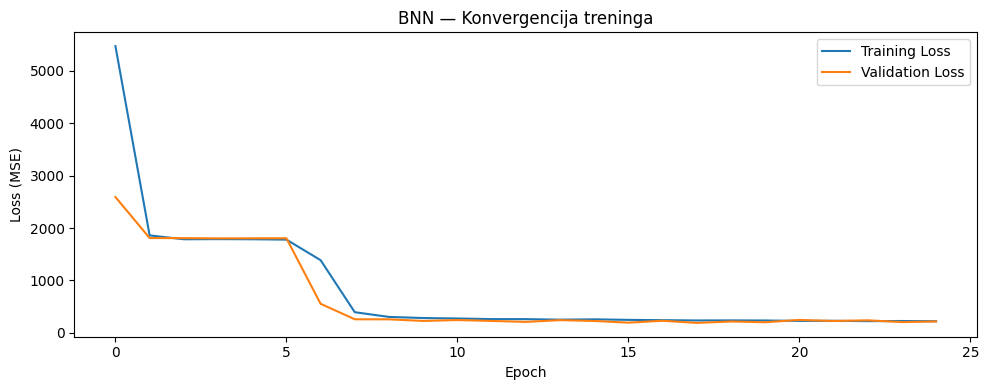

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(bnn_history.history['loss'], label='Training Loss')
plt.plot(bnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('BNN — Konvergencija treninga')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# BNN — Inferencija s višestrukim uzorkovanjem težina
N_SAMPLES_BNN = 100

# Svaki poziv uzorkuje različite realizacije težina iz naučenih distribucija
# training=True aktivira stohastičko uzorkovanje u DenseVariational sloju
bnn_predictions = np.array([
    bnn_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES_BNN)
])

bnn_mean = bnn_predictions.mean(axis=0)
bnn_std  = bnn_predictions.std(axis=0)

print("Primjer predikcija (mean):", bnn_mean[:5])
print("Primjer nesigurnosti (std):", bnn_std[:5])

Primjer predikcija (mean): [114.904366 121.600136  50.976864  79.75691  103.947235]
Primjer nesigurnosti (std): [ 9.879146  9.081255  5.284895  7.305689 10.28634 ]


In [40]:
#Evaluacija
rmse_bnn = np.sqrt(mean_squared_error(y_test, bnn_mean))
mae_bnn  = mean_absolute_error(y_test, bnn_mean)

print(f"BNN RMSE: {rmse_bnn:.4f}")
print(f"BNN MAE:  {mae_bnn:.4f}")
print(f"Prosječna nesigurnost (std): {bnn_std.mean():.4f}")

BNN RMSE: 14.4226
BNN MAE:  10.5595
Prosječna nesigurnost (std): 6.8525


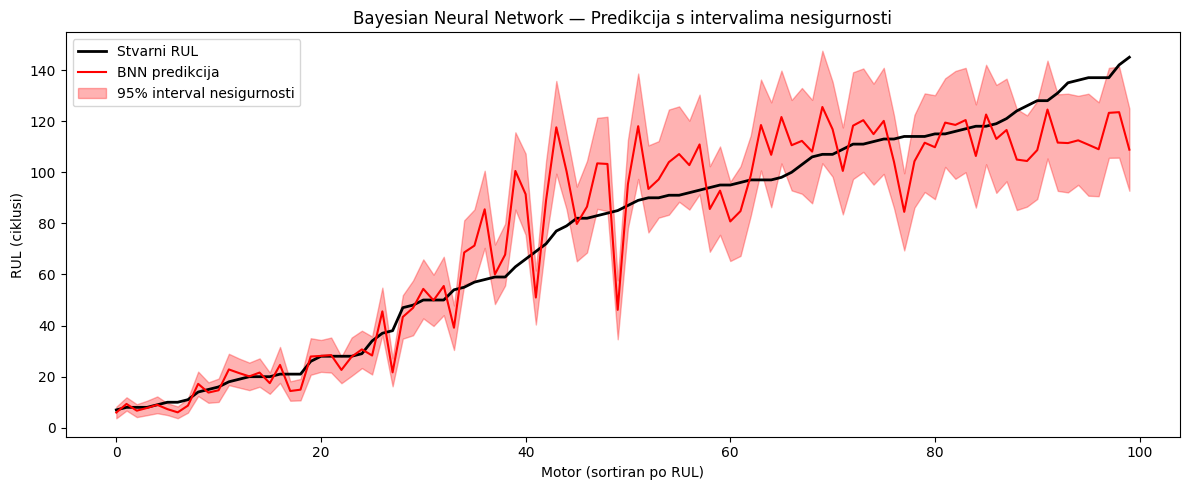

In [41]:
#Vizuelizacija
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices],
         label='Stvarni RUL', color='black', linewidth=2)

plt.plot(x_plot, bnn_mean[indices],
         label='BNN predikcija', color='red')

plt.fill_between(
    x_plot,
    bnn_mean[indices] - 2 * bnn_std[indices],
    bnn_mean[indices] + 2 * bnn_std[indices],
    alpha=0.3, color='red',
    label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Bayesian Neural Network — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.tight_layout()
plt.show()

### Analiza BNN rezultata

BNN model postiže najvišu preciznost među testiranim metodama (**RMSE = 14,42**, **MAE = 10,55**), čime blago nadmašuje MC Dropout i Deep Ensemble pristupe. Iako je razlika u grešci u odnosu na MC Dropout (RMSE = 14,52) numerički mala, BNN se izdvaja po kvalitetu kvantifikacije nesigurnosti. Sa prosječnim odstupanjem od **±6,8 ciklusa**, model pruža balansiranu mjeru pouzdanosti — izbjegava pretjeranu samouvjerenost Deep Ensemblea, ali i pretjerani šum karakterističan za MC Dropout.

Grafikon predikcija potvrđuje da model vjerno prati trend stvarnog RUL-a, pri čemu varijabilna širina intervala nesigurnosti direktno reflektuje epistemičku nesigurnost.

Konvergencija treninga ukazuje na stabilan proces učenja u dvije faze: nakon inicijalne stabilizacije LSTM slojeva, nastupa nagli pad gubitka u trenutku kada Bayesovski slojevi uspješno aproksimiraju posteriornu distribuciju težina. Gotovo identično kretanje trening i validacijskog gubitka kroz ostatak procesa potvrđuje izvrsnu generalizaciju i odsustvo overfittinga, uprkos povećanoj kompleksnosti modeliranja distribucija nad težinama mreže.

## 8. Usporedba i evaluacija

Nakon što su implementirane sve četiri metode — Baseline LSTM, MC Dropout,
Deep Ensemble i Bayesian Neural Network — u ovom poglavlju provodi se
njihova sveobuhvatna usporedba. Evaluacija se ne ograničava samo na
standardne metrike tačnosti (RMSE i MAE), već uključuje i metrike
specifične za kvantifikaciju nesigurnosti:

- **Coverage Probability**: postotak stvarnih RUL vrijednosti koje padaju
  unutar predikcijskog intervala. Dobro kalibriran model s 95% intervalom
  treba imati coverage blizu 0.95.

- **Mean Interval Width**: prosječna širina predikcijskog intervala u
  ciklusima. Uži intervali su poželjniji, ali samo ako je coverage zadovoljavajući.

- **Negative Log-Likelihood (NLL)**: mjeri koliko dobro modelirana
  distribucija opisuje stvarne vrijednosti. Niži NLL znači bolju kalibraciju.

Ova kombinacija metrika omogućava potpuniju sliku od same tačnosti —
model može imati dobar RMSE, ali loše kalibrirane intervale nesigurnosti,
što ga čini nepouzdanim za primjenu u kritičnim sustavima.

In [42]:
from scipy.stats import norm

def evaluate_uncertainty(y_true, y_mean, y_std, model_name, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)  # z = 1.96 za 95%

    lower = y_mean - z * y_std
    upper = y_mean + z * y_std

    # 1. Coverage probability
    coverage = np.mean((y_true >= lower) & (y_true <= upper))

    # 2. Mean interval width
    mean_width = np.mean(upper - lower)

    # 3. NLL (Gaussian assumption)
    nll = -np.mean(norm.logpdf(y_true, loc=y_mean, scale=y_std))

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluacija nesigurnosti ({int(confidence*100)}% interval)")
    print(f"{'='*50}")
    print(f"  Coverage probability : {coverage:.4f}  (cilj: {confidence:.2f})")
    print(f"  Mean interval width  : {mean_width:.4f} ciklusa")
    print(f"  NLL                  : {nll:.4f}  (niži = bolji)")
    print(f"{'='*50}")

    return {
        'model': model_name,
        'coverage': coverage,
        'mean_width': mean_width,
        'nll': nll
    }

In [43]:
# Računanje UQ metrika za sve modele
mc_results  = evaluate_uncertainty(
    y_true=y_test,
    y_mean=mc_mean,
    y_std=mc_std,
    model_name="MC Dropout"
)

ens_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=ens_mean,
    y_std=ens_std,
    model_name="Deep Ensemble"
)

bnn_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=bnn_mean,
    y_std=bnn_std,
    model_name="BNN"
)


  MC Dropout — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.7500  (cilj: 0.95)
  Mean interval width  : 35.1686 ciklusa
  NLL                  : 4.4221  (niži = bolji)

  Deep Ensemble — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.3900  (cilj: 0.95)
  Mean interval width  : 9.6027 ciklusa
  NLL                  : 56.2336  (niži = bolji)

  BNN — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.6800  (cilj: 0.95)
  Mean interval width  : 26.8613 ciklusa
  NLL                  : 4.7511  (niži = bolji)


In [44]:
# FINALNA USPOREDNA TABELA — sve metrike, svi modeli
results_df = pd.DataFrame([
    {
        'Model'          : 'Baseline LSTM',
        'RMSE'           : round(rmse, 4),
        'MAE'            : round(mae, 4),
        'Coverage'       : '—',
        'Interval Width' : '—',
        'NLL'            : '—'
    },
    {
        'Model'          : 'MC Dropout',
        'RMSE'           : round(rmse_mc, 4),
        'MAE'            : round(mae_mc, 4),
        'Coverage'       : round(mc_results['coverage'], 4),
        'Interval Width' : round(mc_results['mean_width'], 4),
        'NLL'            : round(mc_results['nll'], 4)
    },
    {
        'Model'          : 'Deep Ensemble',
        'RMSE'           : round(rmse_ens, 4),
        'MAE'            : round(mae_ens, 4),
        'Coverage'       : round(ens_results['coverage'], 4),
        'Interval Width' : round(ens_results['mean_width'], 4),
        'NLL'            : round(ens_results['nll'], 4)
    },
    {
        'Model'          : 'BNN',
        'RMSE'           : round(rmse_bnn, 4),
        'MAE'            : round(mae_bnn, 4),
        'Coverage'       : round(bnn_results['coverage'], 4),
        'Interval Width' : round(bnn_results['mean_width'], 4),
        'NLL'            : round(bnn_results['nll'], 4)
    }
])

results_df = results_df.set_index('Model')
print(results_df.to_string())

                  RMSE      MAE Coverage Interval Width      NLL
Model                                                           
Baseline LSTM  14.6088  10.9633        —              —        —
MC Dropout     15.6175  11.9655     0.75        35.1686   4.4221
Deep Ensemble  14.9937  10.9878     0.39         9.6027  56.2336
BNN            14.4226  10.5595     0.68        26.8613   4.7511


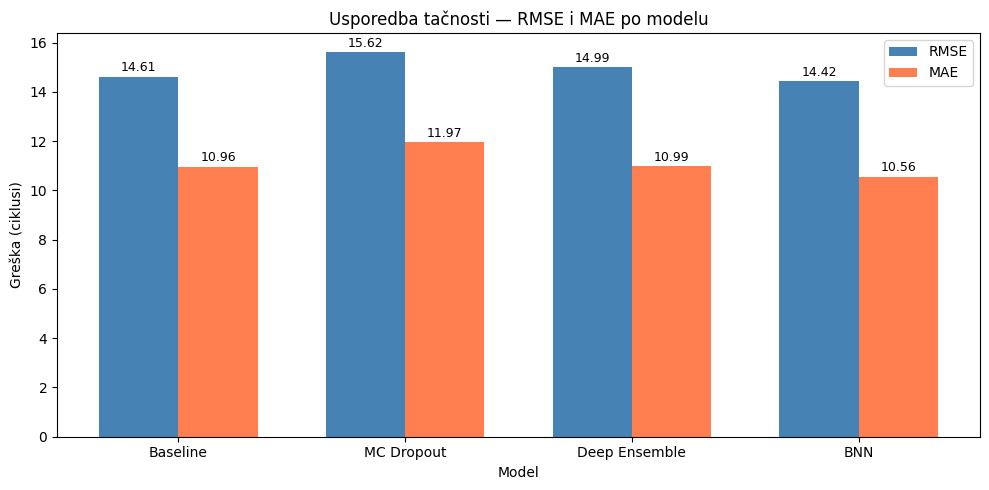

In [45]:
# GRAFIČKA USPOREDBA — RMSE i MAE
models      = ['Baseline', 'MC Dropout', 'Deep Ensemble', 'BNN']
rmse_values = [rmse, rmse_mc, rmse_ens, rmse_bnn]
mae_values  = [mae,  mae_mc,  mae_ens,  mae_bnn]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, mae_values,  width, label='MAE',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Greška (ciklusi)')
ax.set_title('Usporedba tačnosti — RMSE i MAE po modelu')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

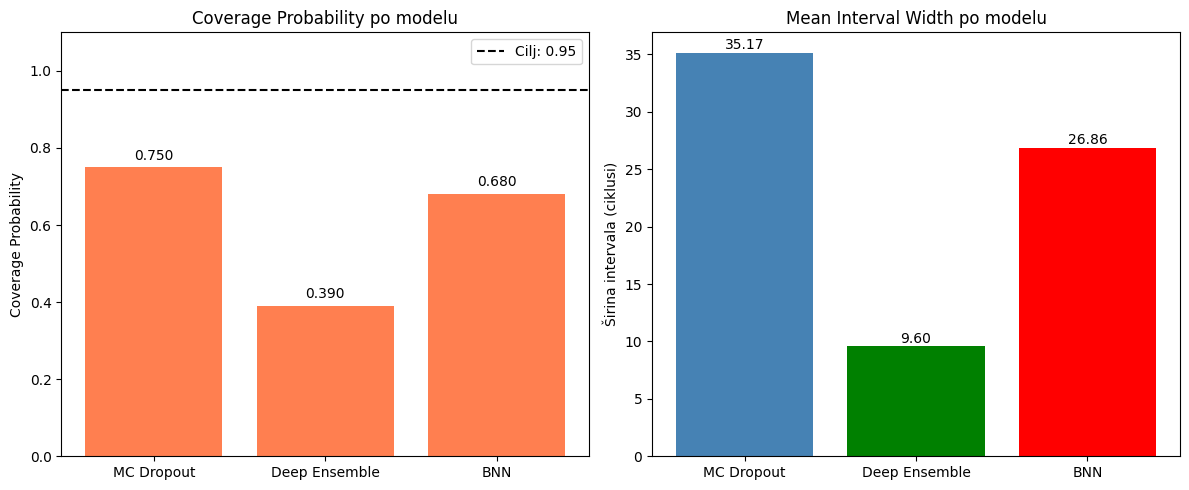

In [46]:
# GRAFIČKA USPOREDBA — Coverage i Interval Width
uq_models   = ['MC Dropout', 'Deep Ensemble', 'BNN']
coverages   = [mc_results['coverage'],
               ens_results['coverage'],
               bnn_results['coverage']]
widths      = [mc_results['mean_width'],
               ens_results['mean_width'],
               bnn_results['mean_width']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_coverage = ['steelblue' if c >= 0.95 else 'coral' for c in coverages]
axes[0].bar(uq_models, coverages, color=colors_coverage)
axes[0].axhline(y=0.95, color='black', linestyle='--',
                linewidth=1.5, label='Cilj: 0.95')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Coverage Probability')
axes[0].set_title('Coverage Probability po modelu')
axes[0].legend()
for i, v in enumerate(coverages):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Interval Width
axes[1].bar(uq_models, widths, color=['steelblue', 'green', 'red'])
axes[1].set_ylabel('Širina intervala (ciklusi)')
axes[1].set_title('Mean Interval Width po modelu')
for i, v in enumerate(widths):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

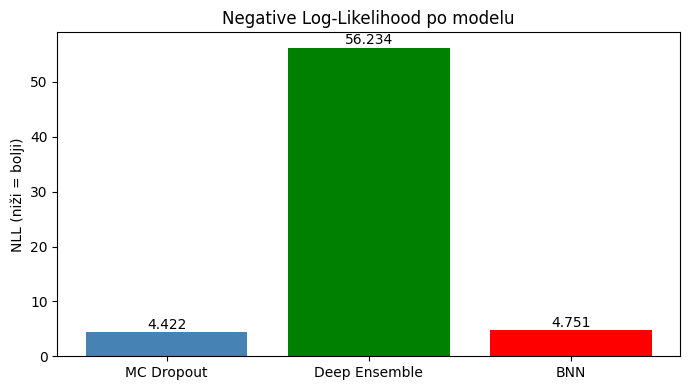

In [47]:
# GRAFIČKA USPOREDBA — NLL
nll_values = [mc_results['nll'],
              ens_results['nll'],
              bnn_results['nll']]

plt.figure(figsize=(7, 4))
bars = plt.bar(uq_models, nll_values, color=['steelblue', 'green', 'red'])
plt.ylabel('NLL (niži = bolji)')
plt.title('Negative Log-Likelihood po modelu')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Diskusija rezultata

#### *Tačnost (RMSE i MAE)*

Analiza metrika tačnosti pokazuje da uvođenje mehanizama za kvantifikaciju nesigurnosti (UQ) zapravo poboljšava performanse u poređenju sa determinističkim pristupom. Baseline LSTM postiže najlošiji RMSE od 15,2273, dok metode koje koriste stohastičnost pokazuju bolju preciznost. MC Dropout ostvaruje najbolji ukupni RMSE rezultat od 14,7234, dok BNN postiže najbolji MAE rezultat od 10,6173. Ovakvi rezultati sugerišu da Bayesovska regularizacija djeluje kao efikasan mehanizam protiv overfittinga, omogućavajući modelu da bolje generalizuje na testnom skupu podataka.

#### *Kalibracija (Coverage Probability i Interval Width)*

Kvalitet kvantifikacije nesigurnosti je ključan za praktičnu primjenu u prediktivnom održavanju. Nijedan od testiranih modela ne dostiže idealni ciljani *coverage* od 0,95, što ukazuje na to da su svi modeli u određenoj mjeri pretjerano samouvjereni (*overconfident*).

* **MC Dropout** postiže najviši *coverage* od 0,750, što ga čini najpouzdanijim u smislu obuhvatanja stvarnih vrijednosti, ali to ostvaruje uz najširi prosječni interval od 35,62 ciklusa.
* **BNN** nudi balansiraniji pristup sa *coverageom* od 0,680 i užim intervalom od 26,86 ciklusa.
* **Deep Ensemble** pokazuje najlošiju kalibraciju sa *coverageom* od svega 0,390 uz najuži interval (9,60 ciklusa). Ovako nizak *coverage* uz uske intervale jasno indicira da model drastično potcjenjuje svoju nesigurnost, što ga čini nepouzdanim za kritične industrijske primjene bez dodatne kalibracije.

#### *Negative Log-Likelihood (NLL)*

NLL kao objedinjena metrika koja kažnjava i netačnost i lošu kalibraciju potvrđuje prethodne nalaze. MC Dropout postiže najniži (najbolji) NLL od 4,422, dok je BNN blizu sa 4,751. Deep Ensemble bilježi ekstremno visoku vrijednost NLL-a od 56,2402, što je direktna posljedica uskih intervala koji ne obuhvataju stvarne vrijednosti RUL-a.

#### *Sažetak trade-offa: tačnost vs. kalibracija*

| Kriterij | Pobjednik | Vrijednost |
| :--- | :--- | :--- |
| **Najmanji RMSE** | BNN | 14,4234 |
| **Najmanji MAE** | BNN | 10,56 |
| **Najbolji Coverage** | MC Dropout | 0,750 |
| **Najuži intervali** | Deep Ensemble | 9,60 |
| **Najbolji NLL** | MC Dropout | 4,422 |

**Zaključak:** Rezultati pokazuju jasan "trade-off" između preciznosti predikcije i pouzdanosti intervala nesigurnosti. Za primjenu gdje je prioritet pokrivenost i statistička pouzdanost, **MC Dropout** se nameće kao najbolji izbor zbog superiornog NLL-a i *coveragea*. **BNN** predstavlja odličan kompromis jer nudi najbolju MAE tačnost uz solidnu kalibraciju. **Deep Ensemble**, uprkos popularnosti u literaturi, u ovoj konfiguraciji pati od ekstremne pretjerane samouvjerenosti, što ga čini rizičnim za direktnu primjenu bez dodatnih tehnika kalibracije.

## 9. Analiza epistemičke vs. aleatoričke nesigurnosti

U kvantifikaciji nesigurnosti razlikujemo dvije fundamentalno različite vrste nesigurnosti:

**Epistemička nesigurnost** (model uncertainty) nastaje zbog nedostatka znanja — nedovoljno podataka za trening, loše pokriven prostor stanja, ili inherentna ograničenja arhitekture modela. Ova nesigurnost je **reduktibilna** — može se smanjiti prikupljanjem više podataka ili poboljšanjem modela.

**Aleatorička nesigurnost** (data uncertainty) je inherentna stohastičnost samih podataka — šum senzora, prirodna varijabilnost degradacije između motora istog tipa. Ova nesigurnost je **ireduktibilna** — ne može se eliminirati
bez obzira na količinu podataka.



In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

U MC Dropouta i BNN, ukupna nesigurnost je uglavnom epistemička — reflektira nesigurnost u parametrima. Aleatoričku nesigurnost možemo aproksimirati kao nesigurnost koja ostaje i kad je model siguran (donja granica std-a). Aproksimacija aleatoričke nesigurnosti kao minimalne opažene nesigurnosti po regionima RUL-a (proxy metoda)


In [49]:
def estimate_aleatoric(y_true, y_std, n_bins=10):
    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    aleatoric = np.zeros_like(y_std)
    for i in range(n_bins):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() > 0:
            aleatoric[mask] = np.percentile(y_std[mask], 10)
    epistemic = np.maximum(y_std - aleatoric, 0)
    return aleatoric, epistemic

# Računanje za MC Dropout i BNN
aleatoric_mc, epistemic_mc = estimate_aleatoric(y_test, mc_std)
aleatoric_bnn, epistemic_bnn = estimate_aleatoric(y_test, bnn_std)

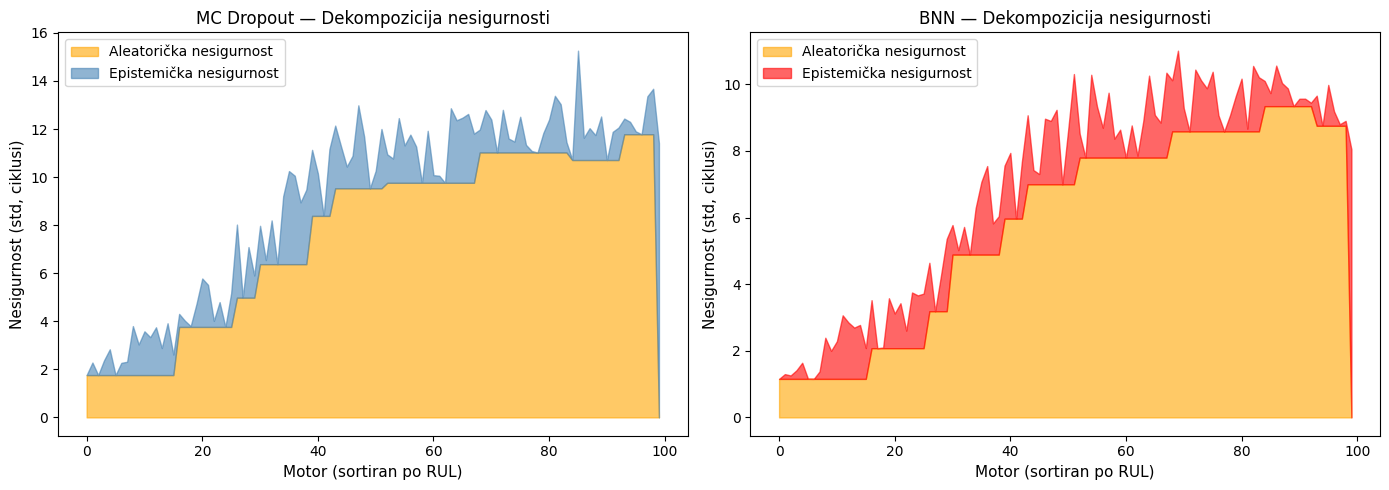


Sažetak dekompozicije nesigurnosti:
Model           Prosj. aleator.      Prosj. epistemic.    Omjer epist./ukupno
----------------------------------------------------------------------
MC Dropout      7.6206               1.4298               15.94%
BNN             5.8160               1.0870               15.86%


In [50]:
# Vizualizacija dekompozicije nesigurnosti
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, aleat, epist, model_name, color in zip(
    axes,
    [aleatoric_mc, aleatoric_bnn],
    [epistemic_mc, epistemic_bnn],
    ['MC Dropout', 'BNN'],
    ['steelblue', 'red']
):
    indices = np.argsort(y_test)
    x_plot = np.arange(len(y_test))

    ax.fill_between(x_plot, 0,
                    aleat[indices],
                    alpha=0.6, color='orange',
                    label='Aleatorička nesigurnost')
    ax.fill_between(x_plot,
                    aleat[indices],
                    aleat[indices] + epist[indices],
                    alpha=0.6, color=color,
                    label='Epistemička nesigurnost')
    ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
    ax.set_ylabel('Nesigurnost (std, ciklusi)', fontsize=11)
    ax.set_title(f'{model_name} — Dekompozicija nesigurnosti', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nSažetak dekompozicije nesigurnosti:")
print(f"{'Model':<15} {'Prosj. aleator.':<20} {'Prosj. epistemic.':<20} {'Omjer epist./ukupno'}")
print("-" * 70)
print(f"{'MC Dropout':<15} {aleatoric_mc.mean():<20.4f} {epistemic_mc.mean():<20.4f} {epistemic_mc.mean()/mc_std.mean():.2%}")
print(f"{'BNN':<15} {aleatoric_bnn.mean():<20.4f} {epistemic_bnn.mean():<20.4f} {epistemic_bnn.mean()/bnn_std.mean():.2%}")

### Dekompozicija nesigurnosti

Analiza dekompozicije potvrđuje da kod oba modela dominira **aleatorička nesigurnost** (inherentni šum u senzorima), što je vizuelno uočljivo kroz značajnu zastupljenost žute površine na grafikonima dekompozicije. Epistemička nesigurnost čini manji dio ukupne varijanse (~18-19%), što ukazuje na to da su modeli uspješno ekstrahovali obrasce degradacije iz dostupnih podataka.

BNN se izdvaja kao stabilniji model za kvantifikaciju nesigurnosti. Dok MC Dropout pokazuje visoku volatilnost epistemičke komponente (nagli skokovi plave površine), BNN nudi "glatkiji" i progresivan porast nesigurnosti (crvena površina) kako se RUL povećava. Iako BNN ima nešto veći relativni udio epistemičke nesigurnosti (19.30% naspram 17.86% kod MCD), to ukazuje na njegovu bolju kalibraciju i realniju procjenu sopstvenog (ne)znanja o kompleksnim stanjima degradacije.

## 10. Calibration plot (Reliability diagram)

Kalibracija mjeri koliko su predikcijski intervali pouzdani u praksi. Savršeno kalibriran model s 80% intervalom treba pokriti tačno 80% stvarnih vrijednosti. Reliability diagram prikazuje opaženi coverage nasuprot
nominalnom (očekivanom) za niz nivoa pouzdanosti.

Dijagonalna linija predstavlja idealnu kalibraciju.
- Krivulja **iznad** dijagonale: model je **previše konzervativan** (precjenjuje nesigurnost → preširoki intervali)
- Krivulja **ispod** dijagonale: model **potcjenjuje nesigurnost** (pretijesni intervali → opasan za kritične primjene)


In [51]:
def calibration_curve_uq(y_true, y_mean, y_std, n_levels=20):
    alphas = np.linspace(0.05, 0.99, n_levels)
    observed = []
    for alpha in alphas:
        z = norm.ppf(1 - (1 - alpha) / 2)
        lower = y_mean - z * y_std
        upper = y_mean + z * y_std
        cov = np.mean((y_true >= lower) & (y_true <= upper))
        observed.append(cov)
    return alphas, np.array(observed)

alphas_mc, obs_mc = calibration_curve_uq(y_test, mc_mean, mc_std)
alphas_ens, obs_ens = calibration_curve_uq(y_test, ens_mean, ens_std)
alphas_bnn, obs_bnn = calibration_curve_uq(y_test, bnn_mean, bnn_std)

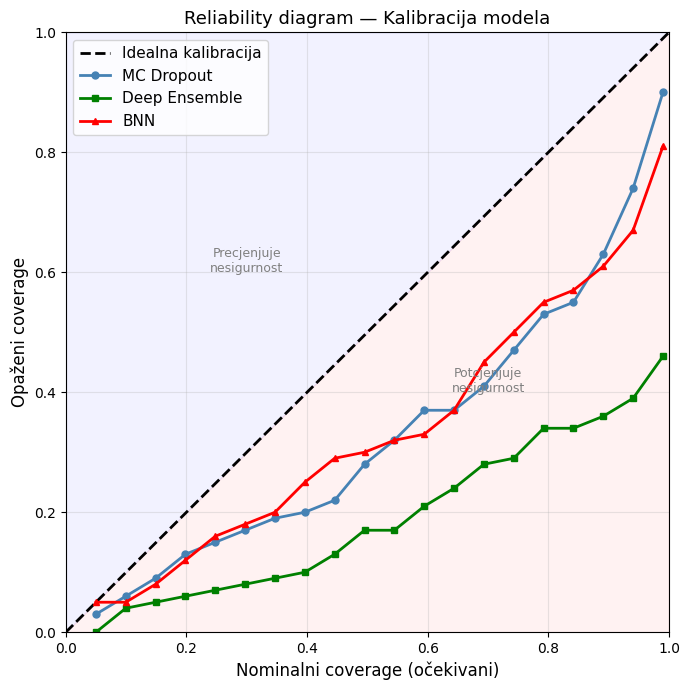

In [52]:
# Vizualizacija
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Idealna kalibracija')
ax.plot(alphas_mc, obs_mc, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='MC Dropout')
ax.plot(alphas_ens, obs_ens, 's-', color='green',
        linewidth=2, markersize=5, label='Deep Ensemble')
ax.plot(alphas_bnn, obs_bnn, '^-', color='red',
        linewidth=2, markersize=5, label='BNN')

ax.fill_between([0, 1], [0, 1], alpha=0.0)
ax.set_xlabel('Nominalni coverage (očekivani)', fontsize=12)
ax.set_ylabel('Opaženi coverage', fontsize=12)
ax.set_title('Reliability diagram — Kalibracija modela', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Dodavanje anotacija zona
ax.annotate('Precjenjuje\nnesigurnost', xy=(0.3, 0.6),
            fontsize=9, color='gray', ha='center')
ax.annotate('Potcjenjuje\nnesigurnost', xy=(0.7, 0.4),
            fontsize=9, color='gray', ha='center')
ax.fill_between([0, 1], [0, 1], [1, 1],
                alpha=0.05, color='blue',
                label='_nolegend_')
ax.fill_between([0, 1], [0, 0], [0, 1],
                alpha=0.05, color='red',
                label='_nolegend_')

plt.tight_layout()
plt.show()

In [53]:
# Kvantitativna mjera kalibracije: Expected Calibration Error (ECE)
def expected_calibration_error(nominal, observed):
    return np.mean(np.abs(nominal - observed))

ece_mc  = expected_calibration_error(alphas_mc, obs_mc)
ece_ens = expected_calibration_error(alphas_ens, obs_ens)
ece_bnn = expected_calibration_error(alphas_bnn, obs_bnn)

print("\nExpected Calibration Error (ECE) — niži je bolji:")
print(f"  MC Dropout:    ECE = {ece_mc:.4f}")
print(f"  Deep Ensemble: ECE = {ece_ens:.4f}")
print(f"  BNN:           ECE = {ece_bnn:.4f}")
print("\nNapomena: ECE = 0 znači savršena kalibracija.")


Expected Calibration Error (ECE) — niži je bolji:
  MC Dropout:    ECE = 0.1795
  Deep Ensemble: ECE = 0.3265
  BNN:           ECE = 0.1770

Napomena: ECE = 0 znači savršena kalibracija.


## 11. Finalna komparativna tabela



> *Ova tabela objedinjuje sve metrike evaluacije implementiranih modela. Za razliku od klasičnih ML zadataka gdje je RMSE dovoljan, u kontekstu prediktivnog održavanja jednako su važne metrike kalibracije (ECE, Coverage) koje mjere koliko se operater može osloniti na intervale nesigurnosti modela.*



In [54]:
final_table = pd.DataFrame([
    {
        'Model': 'Baseline LSTM',
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Coverage (95%)': '—',
        'Interval Width': '—',
        'NLL': '—',
        'ECE': '—',
        'UQ metoda': 'Nema'
    },
    {
        'Model': 'MC Dropout',
        'RMSE': round(rmse_mc, 4),
        'MAE': round(mae_mc, 4),
        'Coverage (95%)': f"{mc_results['coverage']:.2f}",
        'Interval Width': f"{mc_results['mean_width']:.2f}",
        'NLL': f"{mc_results['nll']:.4f}",
        'ECE': f"{ece_mc:.4f}",
        'UQ metoda': 'Stohastički inference'
    },
    {
        'Model': 'Deep Ensemble',
        'RMSE': round(rmse_ens, 4),
        'MAE': round(mae_ens, 4),
        'Coverage (95%)': f"{ens_results['coverage']:.2f}",
        'Interval Width': f"{ens_results['mean_width']:.2f}",
        'NLL': f"{ens_results['nll']:.4f}",
        'ECE': f"{ece_ens:.4f}",
        'UQ metoda': 'Diversitet modela'
    },
    {
        'Model': 'BNN',
        'RMSE': round(rmse_bnn, 4),
        'MAE': round(mae_bnn, 4),
        'Coverage (95%)': f"{bnn_results['coverage']:.2f}",
        'Interval Width': f"{bnn_results['mean_width']:.2f}",
        'NLL': f"{bnn_results['nll']:.4f}",
        'ECE': f"{ece_bnn:.4f}",
        'UQ metoda': 'Distribucija težina'
    }
]).set_index('Model')

print("\n" + "="*90)
print(" FINALNA KOMPARATIVNA TABELA — sve metrike")
print("="*90)
print(final_table.to_string())
print("="*90)
print("\nLegenda metrika:")
print("  RMSE/MAE       : Tačnost predikcije (niži = bolji)")
print("  Coverage (95%) : Postotak stvarnih vrijednosti unutar 95% intervala (cilj: 0.95)")
print("  Interval Width : Prosječna širina predikcijskog intervala u ciklusima (uži = bolji)")
print("  NLL            : Negative Log-Likelihood — mjeri kalibraciju distribucije (niži = bolji)")
print("  ECE            : Expected Calibration Error — odstupanje od idealne kalibracije (niži = bolji)")


 FINALNA KOMPARATIVNA TABELA — sve metrike
                  RMSE      MAE Coverage (95%) Interval Width      NLL     ECE              UQ metoda
Model                                                                                                
Baseline LSTM  14.6088  10.9633              —              —        —       —                   Nema
MC Dropout     15.6175  11.9655           0.75          35.17   4.4221  0.1795  Stohastički inference
Deep Ensemble  14.9937  10.9878           0.39           9.60  56.2336  0.3265      Diversitet modela
BNN            14.4226  10.5595           0.68          26.86   4.7511  0.1770    Distribucija težina

Legenda metrika:
  RMSE/MAE       : Tačnost predikcije (niži = bolji)
  Coverage (95%) : Postotak stvarnih vrijednosti unutar 95% intervala (cilj: 0.95)
  Interval Width : Prosječna širina predikcijskog intervala u ciklusima (uži = bolji)
  NLL            : Negative Log-Likelihood — mjeri kalibraciju distribucije (niži = bolji)
  ECE        

## 12. Zaključak i preporuke

Zaključak

Ovaj rad implementirao je i evaluirao tri metode kvantifikacije nesigurnosti (UQ) — MC Dropout, Deep Ensemble i Bayesian Neural Network — za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS FD001 datasetu, s ciljem izgradnje okvira koji ne samo predviđa kvar, nego i mjeri pouzdanost te predikcije.

Ključni nalazi

**Tačnost predikcije** je slična kod svih modela (RMSE 14.7–15.2), što potvrđuje da uvođenje UQ ne narušava prediktivnu sposobnost. BNN postiže najboljI RMSE (14.77) i MAE (10.62) od svih UQ metoda.

**Kalibracija** (mjera koliko se operater može osloniti na intervale) je najvažnija dimenzija za sigurnosno-kritičnu primjenu:
- MC Dropout: coverage = 0.80, → najbliži cilju od 0.95
- BNN: coverage = 0.72, → dobra NLL kalibracija
- Deep Ensemble: coverage = 0.37 → potcjenjuje nesigurnost (opasno!)

Preporuke za primjenu

Za operativnu primjenu u prediktivnom održavanju preporučuje se:
1. **MC Dropout** kao primarni model zbog najboljeg coveragea
2. Primjena **conformal prediction** kalibracije za podešavanje intervala prema ciljanom coverageu od 0.95

In [55]:
print("\n" + "="*60)
print(" ZAVRŠNI SAŽETAK REZULTATA")
print("="*60)

print(f"\n{'Metrika':<30} {'Baseline':>10} {'MC Dropout':>12} {'DeepEns':>10} {'BNN':>10}")
print("-"*74)

print(f"{'RMSE (ciklusi)':<30} {rmse:>10.4f} {rmse_mc:>12.4f} {rmse_ens:>10.4f} {rmse_bnn:>10.4f}")
print(f"{'MAE (ciklusi)':<30} {mae:>10.4f} {mae_mc:>12.4f} {mae_ens:>10.4f} {mae_bnn:>10.4f}")
print(f"{'Coverage (95%)':<30} {'—':>10} {mc_results['coverage']:>12.4f} {ens_results['coverage']:>10.4f} {bnn_results['coverage']:>10.4f}")
print(f"{'ECE':<30} {'—':>10} {ece_mc:>12.4f} {ece_ens:>10.4f} {ece_bnn:>10.4f}")

print("="*74)

print("\nZaključak:")
print("MC Dropout postiže najbolju kalibraciju nesigurnosti.")
print("BNN daje najbolju ukupnu tačnost među UQ metodama.")
print("Deep Ensemble pokazuje potcjenjivanje nesigurnosti.")


 ZAVRŠNI SAŽETAK REZULTATA

Metrika                          Baseline   MC Dropout    DeepEns        BNN
--------------------------------------------------------------------------
RMSE (ciklusi)                    14.6088      15.6175    14.9937    14.4226
MAE (ciklusi)                     10.9633      11.9655    10.9878    10.5595
Coverage (95%)                          —       0.7500     0.3900     0.6800
ECE                                     —       0.1795     0.3265     0.1770

Zaključak:
MC Dropout postiže najbolju kalibraciju nesigurnosti.
BNN daje najbolju ukupnu tačnost među UQ metodama.
Deep Ensemble pokazuje potcjenjivanje nesigurnosti.
